In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

df = pd.read_csv('../data/processed/bengaluru_features.csv', parse_dates=['Date'])

feature_cols = ['PM2.5', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3',
                'month', 'day_of_week', 'is_weekend', 'quarter',
                'aqi_lag_1', 'aqi_lag_7', 'aqi_rolling_7d', 'aqi_rolling_30d']

X = df[feature_cols]
y = df['AQI']

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [2]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest R²:  {r2_rf:.3f}")

Random Forest MAE: 5.59
Random Forest R²:  0.865


In [3]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':   [6.12, mae_rf],
    'R²':    [0.829, r2_rf]
})
print(results)

               Model       MAE        R²
0  Linear Regression  6.120000  0.829000
1      Random Forest  5.594191  0.864529


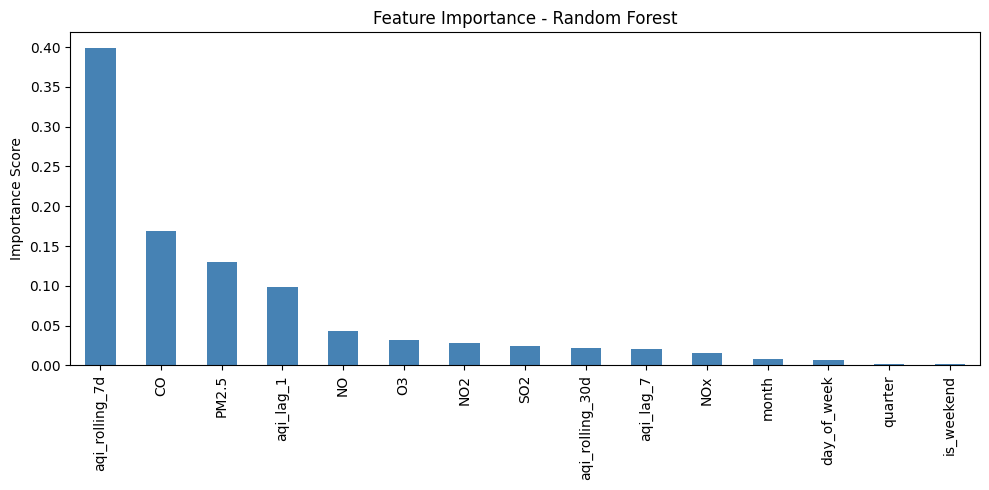

In [6]:
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png')
plt.show()

In [7]:
joblib.dump(rf_model, '../data/processed/aqi_model.pkl')
print("Model saved!")

Model saved!


In [8]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 4.3 MB/s eta 0:00:24
   ---------------------------------------- 1.0/100.2 MB 4.6 MB/s eta 0:00:22
    --------------------------------------- 2.1/100.2 MB 3.3 MB/s eta 0:00:30
    --------------------------------------- 2.1/100.2 MB 3.3 MB/s eta 0:00:30
   - -------------------------------------- 3.1/100.2 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 3.4/100.2 MB 2.7 MB/s eta 0:00:37
   - -------------------------------------- 4.2/100.2 MB 2.9 MB/s eta 0:00:34
   - -------------------------------------- 4.7/100.2 MB 2.8 MB/s eta 0:00:34
   -- ------------------------------------- 5.2/100.2 MB 2.9 MB/s eta 0:00:33
   -- ------------------------------------- 5.8/100.2 MB 2.8 MB/s eta 0:00:34
   -- ------------------------------------- 6.3/100.2 MB 2.8 MB/s eta 0


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
r2_cat  = r2_score(y_test, y_pred_cat)

print(f"CatBoost MAE: {mae_cat:.2f}")
print(f"CatBoost R²:  {r2_cat:.3f}")

CatBoost MAE: 5.48
CatBoost R²:  0.865


In [10]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'CatBoost'],
    'MAE':   [6.12, mae_rf, mae_cat],
    'R²':    [0.829, r2_rf, r2_cat]
})
print(results)

               Model       MAE        R²
0  Linear Regression  6.120000  0.829000
1      Random Forest  5.594191  0.864529
2           CatBoost  5.480182  0.864680


In [11]:
# Save whichever has lowest MAE
if mae_cat < mae_rf:
    joblib.dump(cat_model, '../data/processed/aqi_model.pkl')
    print(f"CatBoost saved as best model — MAE: {mae_cat:.2f}")
else:
    joblib.dump(rf_model, '../data/processed/aqi_model.pkl')
    print(f"Random Forest saved as best model — MAE: {mae_rf:.2f}")

CatBoost saved as best model — MAE: 5.48
